In [1]:
# ===============================
# 0. GPU Check + Drive Mount
# ===============================
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Using GPU: ", tf.test.gpu_device_name())

from google.colab import drive
drive.mount('/content/drive')

# ===============================
# 1. Install requirements & Extract Dataset
# ===============================
!apt install unrar
!pip install pyunpack patool transformers

from pyunpack import Archive
import os

rar_path = '/content/drive/MyDrive/Colab Dataset/data.rar'
extract_path = '/content/Dataset'
os.makedirs(extract_path, exist_ok=True)
Archive(rar_path).extractall(extract_path)

Num GPUs Available:  1
Using GPU:  /device:GPU:0
Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.5/86.5 kB 4.0 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ===============================
# 3. Dataset Preparation
# ===============================
data_root = '/content/Dataset/data/Recognition'  # Change if needed
train_dir = os.path.join(data_root, 'train')
val_dir   = os.path.join(data_root, 'validation')
test_dir  = os.path.join(data_root, 'test')

image_size = (256, 256)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=True, seed=seed
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False, seed=seed
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 26097 files belonging to 9 classes.
Found 1634 files belonging to 9 classes.
Found 1144 files belonging to 9 classes.
Classes: ['1000_taka', '100_taka', '10_taka', '200_taka', '20_taka', '2_taka', '500_taka', '50_taka', '5_taka']


In [4]:
# ===============================
# Create ResNet50 Model
# ===============================
def create_resnet_model(input_shape=(256,256,3), num_classes=9, trainable=False):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = trainable  # Freeze backbone initially

    inputs = layers.Input(shape=input_shape)
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='ResNet50_currency')
    return model

model = create_resnet_model(input_shape=(256,256,3), num_classes=num_classes, trainable=False)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_currency"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 256, 256)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 256, 256)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 256, 256)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 256, 256,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 8, 8,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9)         │      2,313 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,115,593 (91.99 MB)

 Trainable params: 527,369 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [5]:
# ===============================
# Compile Model
# ===============================
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ===============================
# Callbacks
# ===============================
checkpoint_path = "best_resnet_model.h5"
callbacks = [
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

In [7]:
# ===============================
# Train Model (Transfer Learning)
# ===============================
epochs = 20  # Frozen backbone
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6054 - loss: 1.2581
Epoch 1: val_loss improved from inf to 0.10892, saving model to best_resnet_model.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 123s 135ms/step - accuracy: 0.6056 - loss: 1.2574 - val_accuracy: 0.9755 - val_loss: 0.1089 - learning_rate: 1.0000e-04
Epoch 2/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9420 - loss: 0.1989
Epoch 2: val_loss improved from 0.10892 to 0.05854, saving model to best_resnet_model.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 87s 107ms/step - accuracy: 0.9420 - loss: 0.1989 - val_accuracy: 0.9853 - val_loss: 0.0585 - learning_rate: 1.0000e-04
Epoch 3/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9716 - loss: 0.1065
Epoch 3: val_loss improved from 0.05854 to 0.03536, saving model to best_resnet_model.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 107ms/step - accuracy: 0.9716 - loss: 0.1065 - val_accuracy: 0.9871 - val_loss: 0.0354 - learning_rate: 1.0000e-04
Epoch 4/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9840 - loss: 0.0654
Epoch 4: val_loss improved from 0.03536 to 0.02754, saving model to best_resnet_model.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 107ms/step - accuracy: 0.9840 - loss: 0.0654 - val_accuracy: 0.9927 - val_loss: 0.0275 - learning_rate: 1.0000e-04
Epoch 5/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9885 - loss: 0.0467
Epoch 5: val_loss improved from 0.02754 to 0.02279, saving model to best_resnet_model.h5


...

816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 107ms/step - accuracy: 0.9909 - loss: 0.0399 - val_accuracy: 0.9939 - val_loss: 0.0221 - learning_rate: 1.0000e-04
Epoch 7/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9943 - loss: 0.0265
Epoch 7: val_loss improved from 0.02208 to 0.01875, saving model to best_resnet_model.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 86s 106ms/step - accuracy: 0.9943 - loss: 0.0265 - val_accuracy: 0.9927 - val_loss: 0.0187 - learning_rate: 1.0000e-04
Epoch 8/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9962 - loss: 0.0209
Epoch 8: val_loss improved from 0.01875 to 0.01600, saving model to best_resnet_model.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 106ms/step - accuracy: 0.9962 - loss: 0.0209 - val_accuracy: 0.9951 - val_loss: 0.0160 - learning_rate: 1.0000e-04
Epoch 9/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9964 - loss: 0.0170
Epoch 9: val_loss improved from 0.01600 to 0.01441, saving model to best_resnet_model.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 106ms/step - accuracy: 0.9964 - loss: 0.0170 - val_accuracy: 0.9945 - val_loss: 0.0144 - learning_rate: 1.0000e-04
Epoch 10/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9972 - loss: 0.0143
Epoch 10: val_loss did not improve from 0.01441
816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 106ms/step - accuracy: 0.9972 - loss: 0.0143 - val_accuracy: 0.9927 - val_loss: 0.0175 - learning_rate: 1.0000e-04
Epoch 11/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9962 - loss: 0.0149
Epoch 11: val_loss did not improve from 0.01441
816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 105ms/step - accuracy: 0.9962 - loss: 0.0149 - val_accuracy: 0.9933 - val_loss: 0.0178 - learning_rate: 1.0000e-04
Epoch 12/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9979 - loss: 0.0111
Epoch 12: val_loss improved from 0.01441 to 0.01109, saving model to best_resnet_model.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 143s 106ms/step - accuracy: 0.9979 - loss: 0.0111 - val_accuracy: 0.9957 - val_loss: 0.0111 - learning_rate: 1.0000e-04
Epoch 13/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9975 - loss: 0.0113
Epoch 13: val_loss did not improve from 0.01109
816/816 ━━━━━━━━━━━━━━━━━━━━ 141s 105ms/step - accuracy: 0.9975 - loss: 0.0113 - val_accuracy: 0.9945 - val_loss: 0.0140 - learning_rate: 1.0000e-04
Epoch 14/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9986 - loss: 0.0086
Epoch 14: val_loss did not improve from 0.01109
816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 105ms/step - accuracy: 0.9986 - loss: 0.0086 - val_accuracy: 0.9945 - val_loss: 0.0176 - learning_rate: 1.0000e-04
Epoch 15/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9985 - loss: 0.0080 
Epoch 15: val_loss did not improve from 0.01109

Epoch 15: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
816/816 ━━━━━━━━━━━━━━━━━━━━ 142s 105ms/step - accuracy: 0.9985 - 

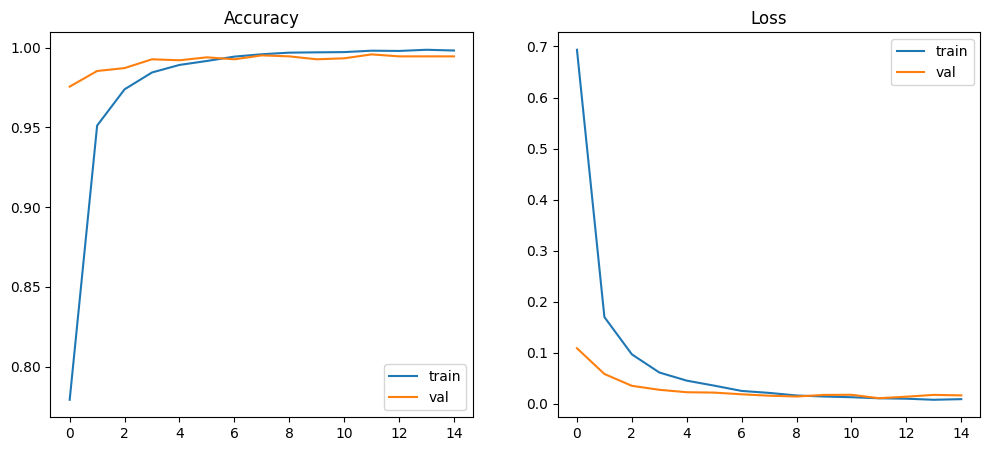

In [9]:
# ===============================
# Plot Training History
# ===============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()


In [10]:
# ===============================
# Evaluate on Test Dataset
# ===============================
y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

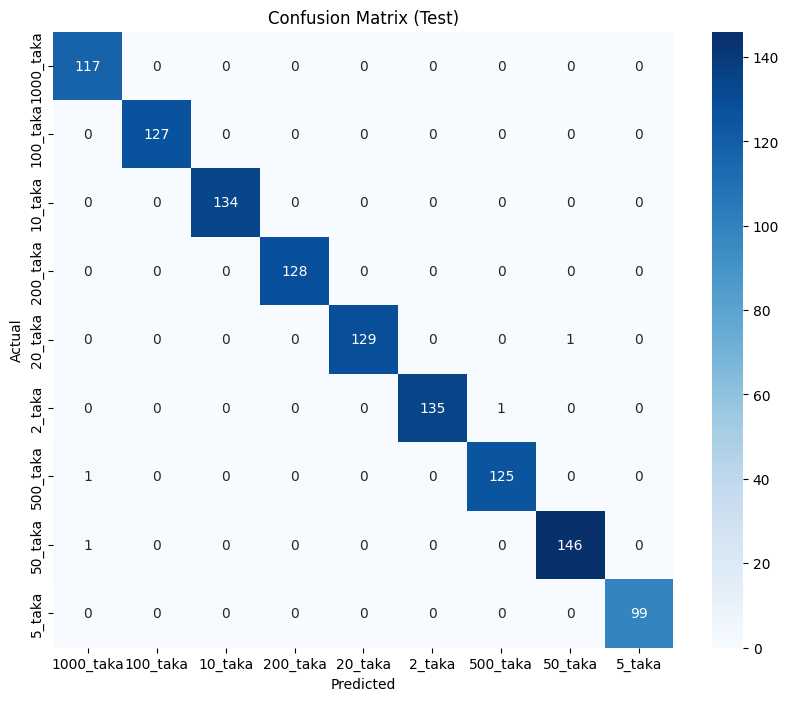

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test)')
plt.show()


In [12]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

   1000_taka       0.98      1.00      0.99       117
    100_taka       1.00      1.00      1.00       127
     10_taka       1.00      1.00      1.00       134
    200_taka       1.00      1.00      1.00       128
     20_taka       1.00      0.99      1.00       130
      2_taka       1.00      0.99      1.00       136
    500_taka       0.99      0.99      0.99       126
     50_taka       0.99      0.99      0.99       147
      5_taka       1.00      1.00      1.00        99

    accuracy                           1.00      1144
   macro avg       1.00      1.00      1.00      1144
weighted avg       1.00      1.00      1.00      1144

